## PART B — DATA ANALYSIS & TESTING

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm

In [4]:
df = pd.read_csv("spread_locator_dataset - spread_locator_dataset.csv.csv")
df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


In [5]:
df.info()
df.describe()

df['transaction_date'] = pd.to_datetime(df['transaction_date'])

df = df.dropna()

<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      220 non-null    str    
 1   customer_id         220 non-null    str    
 2   transaction_amount  220 non-null    float64
 3   transaction_date    220 non-null    str    
 4   transaction_count   220 non-null    int64  
 5   region              220 non-null    str    
 6   transaction_status  220 non-null    str    
dtypes: float64(1), int64(1), str(5)
memory usage: 25.9 KB


## TASK 1 - Bernoulli & Binomial Distribution

In [6]:
df['status_binary'] = df['transaction_status'].map({'Success':1, 'Fail':0})

p = df['status_binary'].mean()
print("Probability of Success : ", p)

Probability of Success :  0.44545454545454544


Bernoulli = only 2 outcomes (Success/Fail)

We convert status into 1 and 0

Mean gives probability of success

In [7]:
weekly = df.groupby('customer_id')['transaction_count'].sum()

n = weekly.max() 
p = weekly.mean() / n

binomial_prob = stats.binom.pmf(5, n, p)
print("Binomial Probability :", binomial_prob)

Binomial Probability : 0.09177239956311453


### Interpretation :-

Binomial distribution shows probability of a fixed number of transactions in a given period.

The calculated probability tells how likely a customer makes k transactions in a week.

If probability is low → such behavior is rare

If high → common customer behavior

### Helps in :-

Predicting customer activity

Planning offers & engagement

## TASK 2 - Poisson Distribution

In [8]:
daily_counts = df.groupby('transaction_date').size()

lambda_val = daily_counts.mean()

poisson_probability = stats.poisson.pmf(3, lambda_val)
print("Poisson Probability :", poisson_probability)

Poisson Probability : 0.04931077622299057


### Interpretation :- 

The average transaction rate (λ) represents how many transactions happen per day.

Poisson probability shows likelihood of a certain number of daily transactions.

If actual data matches Poisson → transactions occur randomly but at a stable rate

## TASK 3: Log-Normal & Power Law

### Log - Normal Distribution

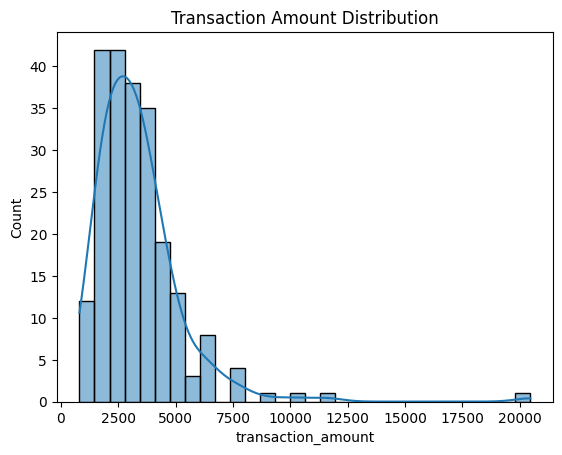

In [9]:
amount = df['transaction_amount']

shape, loc, scale = stats.lognorm.fit(amount)

sns.histplot(amount, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()

### Power Law Distribution

In [10]:
fit = stats.powerlaw.fit(amount)
print("Power Law Parameters :", fit)

Power Law Parameters : (np.float64(0.41232325172331613), np.float64(804.4199999999998), np.float64(19658.420000000006))


### Interpretation :- 

Power law suggests heavy tail behavior.

A small number of transactions contribute to a large portion of revenue.

#### Business Insight :-

80-20 rule applies (Pareto principle)

Focus marketing on top spenders

### TASK 4 - Q-Q Plot

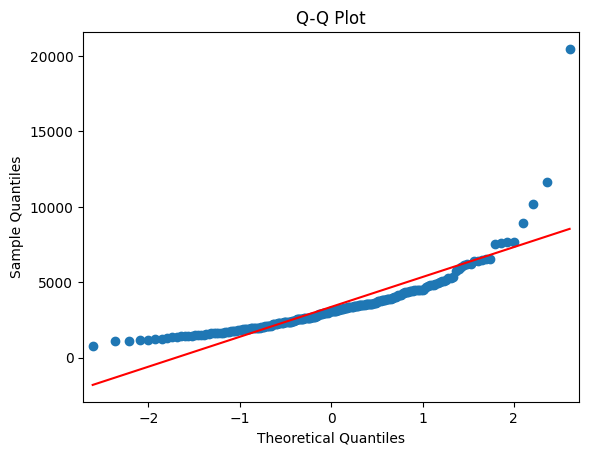

In [11]:
sm.qqplot(amount, line='s')
plt.title("Q-Q Plot")
plt.show()

### Interpretation :-

If points are not perfectly on the straight line → data is NOT normally distributed.

Deviations at ends indicate skewness or outliers.

Transaction data is not normal → need transformation

### TASK 5 - Box-Cox Transformation

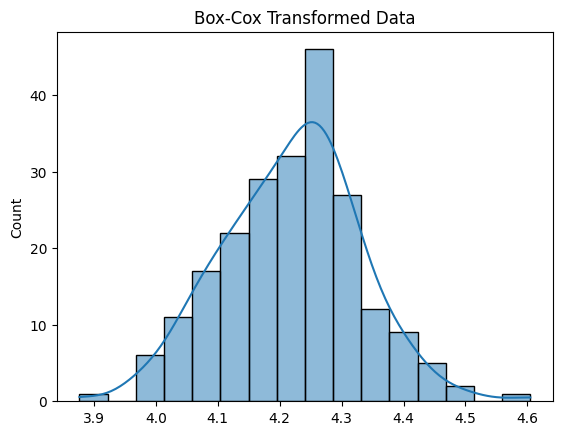

In [ ]:
amount_positive = amount + 1 

transformed, lambda_val = stats.boxcox(amount_positive)

sns.histplot(transformed, kde=True)
plt.title("Box-Cox Transformed Data")
##plt.show()

### Interpretation :-

After transformation, data becomes more symmetric (closer to normal).

This improves statistical modeling and ML performance.

## TASK 6 - Z-Score & Probability

In [13]:
mean = amount.mean()
std = amount.std()

z_scores = (amount - mean) / std

probability = 1 - stats.norm.cdf(5000, mean, std)
print("Probability of transactions > 5000 :", probability)

Probability of transactions > 5000 : 0.20517209567554384


### Interpretation :-

Z-score identifies how far transactions are from average.

Very high Z-score → potential outliers (big spenders or fraud )

Probability of transactions > ₹5000 tells how rare high-value transactions are.

## TASK 7 - PDF & CDF

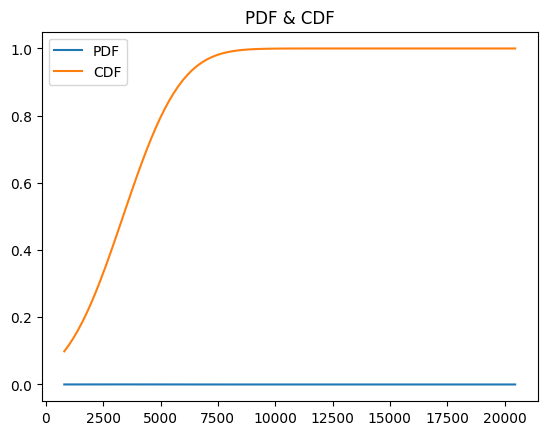

In [14]:
x = np.linspace(min(amount), max(amount), 100)

pdf = stats.norm.pdf(x, mean, std)
cdf = stats.norm.cdf(x, mean, std)

plt.plot(x, pdf, label="PDF")
plt.plot(x, cdf, label="CDF")
plt.legend()
plt.title("PDF & CDF")
plt.show()

### Interpretation :-

PDF shows where most values are concentrated.

CDF shows cumulative probability (how much data lies below a value).

### Example Insight :-

If CDF at ₹5000 = 0.9 → 90% transactions are below ₹5000

## Task - 8 Final Conclusion 

Data is skewed → not normal

Log-normal & power law fit better

High-value transactions are rare but impactful

Poisson fits transaction frequency

Box-Cox improves analysis